<a href="https://colab.research.google.com/github/samitha278/EN3160-IPCV/blob/main/fitting_and_alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import gdown
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1

In [5]:
# Data file download

file_id = "1v67HJVO_KJ_O9LRwu6D0C4aKpq9IV4xm"
url = f"https://drive.google.com/uc?id={file_id}"

output = "sunflower.jpeg"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1v67HJVO_KJ_O9LRwu6D0C4aKpq9IV4xm
To: /content/sunflower.jpeg
100%|██████████| 224k/224k [00:00<00:00, 58.8MB/s]


'sunflower.jpeg'

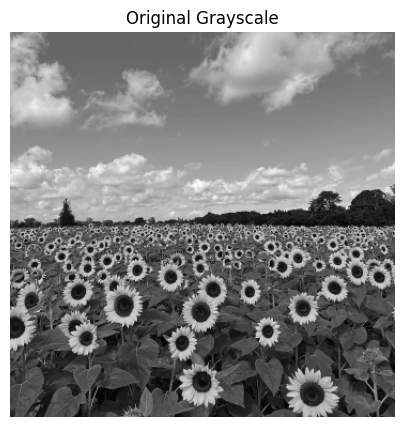

In [8]:
img = cv.imread(output, cv.IMREAD_REDUCED_COLOR_4)
assert img is not None
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY) / 255

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Original Grayscale')
plt.show()

In [12]:
sigma_min = 1
sigma_max = 15
num_scales = 15
thresh = 0.1
k = 1

sigmas = np.linspace(sigma_min, sigma_max, num_scales) / 1.414

all_blobs = []

for s in sigmas:
    print(f"{s:.2f}", end=", ")
    hw = round(3 * s)
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))

    # LoG kernel
    log_kernel = ((X**2 + Y**2) / (2 * s**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * s**2)) / (np.pi * s**4)
    log_kernel = s**2 * log_kernel

    response = np.square(cv.filter2D(gray, -1, log_kernel))

    # Find local maxima
    H, W = response.shape
    for i in range(k, H - k):
        for j in range(k, W - k):
            patch = response[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(patch) >= thresh:
                x, y = np.unravel_index(patch.argmax(), patch.shape)
                all_blobs.append((i + x - k, j + y - k, s))

print(f"\nTotal blobs: {len(all_blobs)}")

0.71, 1.41, 2.12, 2.83, 3.54, 4.24, 4.95, 5.66, 6.36, 7.07, 7.78, 8.49, 9.19, 9.90, 10.61, 
Total blobs: 1192


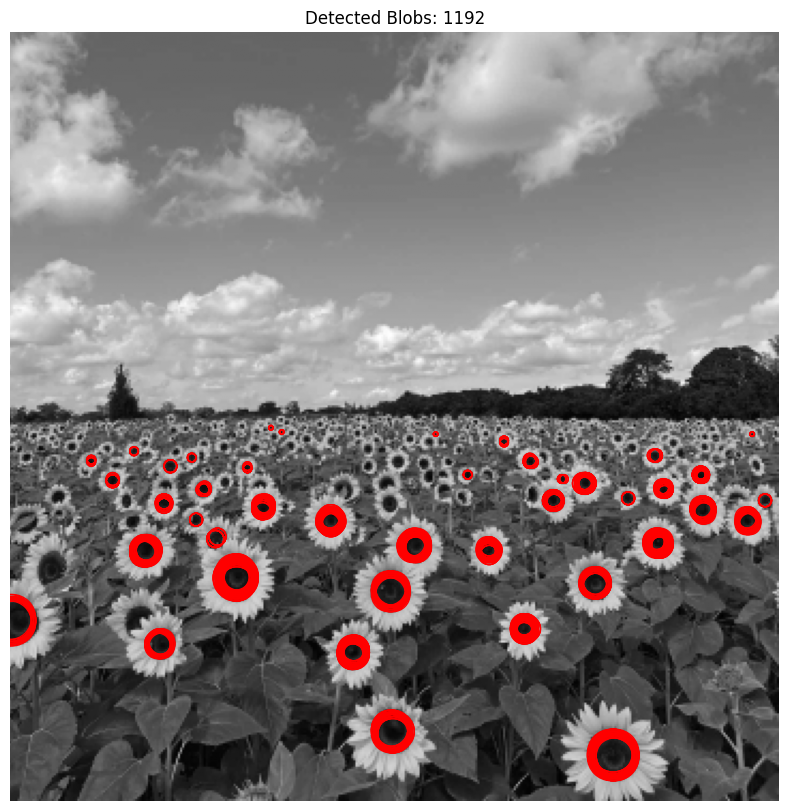

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray, cmap='gray')

for y, x, s in all_blobs:
    circle = plt.Circle((x, y), s * 1.414, color='r', linewidth=1, fill=False)
    ax.add_patch(circle)

ax.set_xlim([0, gray.shape[1]])
ax.set_ylim([gray.shape[0], 0])
ax.axis('off')
plt.title(f'Detected Blobs: {len(all_blobs)}')
plt.show()


σ range: [0.71, 10.61]

Top 10 Largest Circles:
Rank   Y        X        Sigma      Radius    
---------------------------------------------
1      274.0    0.0      7.78       11.00     
2      274.0    1.0      7.78       11.00     
3      275.0    0.0      7.78       11.00     
4      275.0    1.0      7.78       11.00     
5      275.0    0.0      7.78       11.00     
6      275.0    1.0      7.78       11.00     
7      275.0    0.0      7.78       11.00     
8      275.0    1.0      7.78       11.00     
9      276.0    0.0      7.78       11.00     
10     276.0    1.0      7.78       11.00     


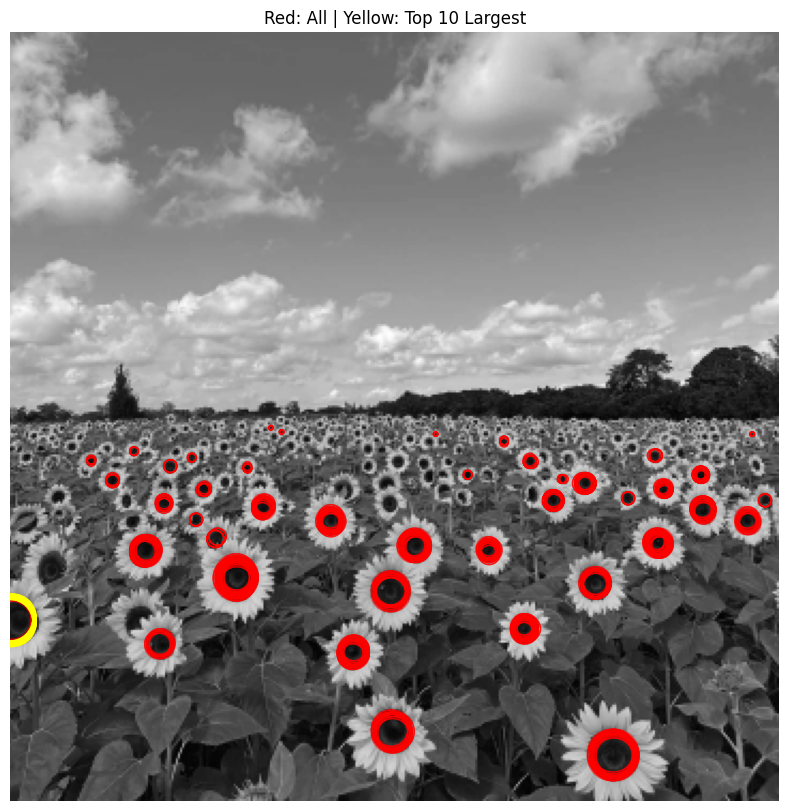

In [15]:
blobs_sorted = sorted(all_blobs, key=lambda b: b[2], reverse=True)

print(f"\nσ range: [{sigmas[0]:.2f}, {sigmas[-1]:.2f}]")
print(f"\nTop 10 Largest Circles:")
print(f"{'Rank':<6} {'Y':<8} {'X':<8} {'Sigma':<10} {'Radius':<10}")
print("-" * 45)

for i, (y, x, s) in enumerate(blobs_sorted[:10]):
    r = s * 1.414
    print(f"{i+1:<6} {y:<8.1f} {x:<8.1f} {s:<10.2f} {r:<10.2f}")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray, cmap='gray')

# All blobs in red
for y, x, s in all_blobs:
    circle = plt.Circle((x, y), s * 1.414, color='r', linewidth=1, fill=False, alpha=0.5)
    ax.add_patch(circle)

# Top 10 in yellow
for y, x, s in blobs_sorted[:10]:
    circle = plt.Circle((x, y), s * 1.414, color='yellow', linewidth=2, fill=False)
    ax.add_patch(circle)

ax.set_xlim([0, gray.shape[1]])
ax.set_ylim([gray.shape[0], 0])
ax.axis('off')
plt.title('Red: All | Yellow: Top 10 Largest')
plt.show()